# Monte Carlo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')
from src.monte_carlo import simulate_gbm_terminal, compute_payoff, mc_option_price
from src.black_scholes import bs_option_price

## Monte Carlo Convergence to Black Scholes Analytical Price

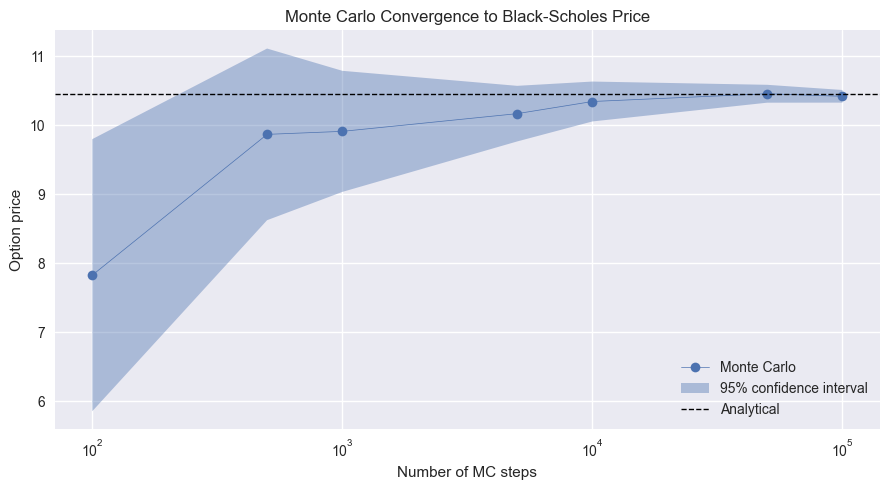

In [8]:
spot, strike, rate, sigma, expiry = 100, 100, 0.05, 0.2, 1.0
bs_price = bs_option_price(spot, strike, rate, sigma, expiry, option_type="call")

n_values = [100, 500, 1000, 5000, 10000, 50000, 100000]
prices = []
errors = []

for N in n_values:
    terminal = simulate_gbm_terminal(
        spot, rate, sigma, expiry, n_simulations=N, seed=42
    )
    payoff = compute_payoff(terminal, strike, option_type="call")
    price, stderr = mc_option_price(payoff, rate, expiry)
    prices.append(price)
    errors.append(stderr)

prices = np.array(prices)
errors = np.array(errors)


plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(9, 5))

# 1. plot MC prices as a line with markers
ax.plot(n_values, prices, "o-", linewidth=0.5, label="Monte Carlo")

# 2. shade confidence interval with ax.fill_between
ax.fill_between(
    n_values,
    prices - 1.96 * errors,
    prices + 1.96 * errors,
    alpha=0.4,
    label="95% confidence interval",
)

# 3. horizontal dashed line for BS price
ax.axhline(y=bs_price, linestyle="--", color="black", linewidth=1, label="Analytical")

# 4. log scale on x-axis — ax.set_xscale('log')
ax.set_xscale("log")

# 5. labels, title, legend
ax.set_title("Monte Carlo Convergence to Black-Scholes Price")
ax.set_xlabel("Number of MC steps")
ax.set_ylabel("Option price")
ax.legend()

plt.tight_layout()
plt.savefig("../results/02_mc_convergence_to_bs.png", dpi=150)
plt.show()

In [3]:
print(errors[0])   # N=100
print(errors[4])   # N=10,000

1.0068898991922248
0.14765527406207832


1. **The estimate is biased low for small N**: At $N=100$ the MC price is $\approx 7.8$, well below the analytical 10.45. This isn't just noise — with only 100 paths we systematically undersampling the right tail of the log-normal distribution where large payoffs live. The mean of 100 draws is a poor estimate of the true expectation.


2. **The confidence interval is asymmetric**: At $N=500$, the upper band reaches $\approx 11$, the lower band drops to $\approx 8.5$. The interval is wider below than above. This reflects the skewness of the payoff distribution — most paths have zero payoff, a few have large payoffs. The standard error captures variance but not skewness.


3. **The funnel narrows as $\frac{1}{\sqrt{N}}$**: At $N=100$ the band width is $\approx 5$. At $N=10,000$ (100 $\times$ more) it should be $\approx 0.5$, exactly $10 \times$ narrower.

## Distribution of the Terminal Stock Prices

In [4]:
terminal = simulate_gbm_terminal(
    spot, rate, sigma, expiry, n_simulations=100000, seed=42
    )
terminal.shape

(100000,)

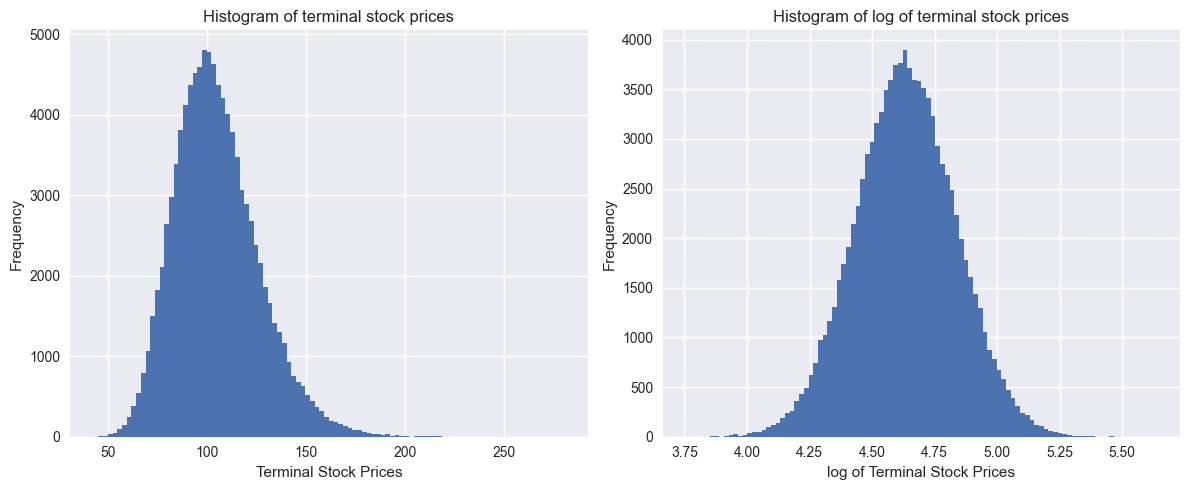

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
ax0.hist(terminal, bins=100, edgecolor="none")
ax0.set_xlabel("Terminal Stock Prices")
ax0.set_ylabel("Frequency")
ax0.set_title("Histogram of terminal stock prices")

log_terminal = np.log(terminal)
ax1.hist(log_terminal, bins=100, edgecolor="none")
ax1.set_xlabel("log of Terminal Stock Prices")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram of log of terminal stock prices")

plt.tight_layout()
plt.show()

In [6]:
print(f"Theoretical mean: {np.log(100) + (0.05 - 0.5*0.2**2)*1.0:.4f}")
print(f"Simulated mean:   {np.log(terminal).mean():.4f}")

Theoretical mean: 4.6352
Simulated mean:   4.6343


1. **The log-normal skew is visible:** The left histogram peaks around 95-100 and has a long right tail. This is the asymmetry in the stock prices as the stock prices can rise without bound but can't go below zero. The right tail represents the rare but large upside moves that dominate the option's expected payoff.

2. **The log histogram is approximately normal:** The right histogram is symmetric and bell-shaped confirming GBM. The mean of log(S_T) should be:
$$\mu_{\ln S} = \ln(S_0) + \left(r - \frac{1}{2}\sigma^2\right)T$$

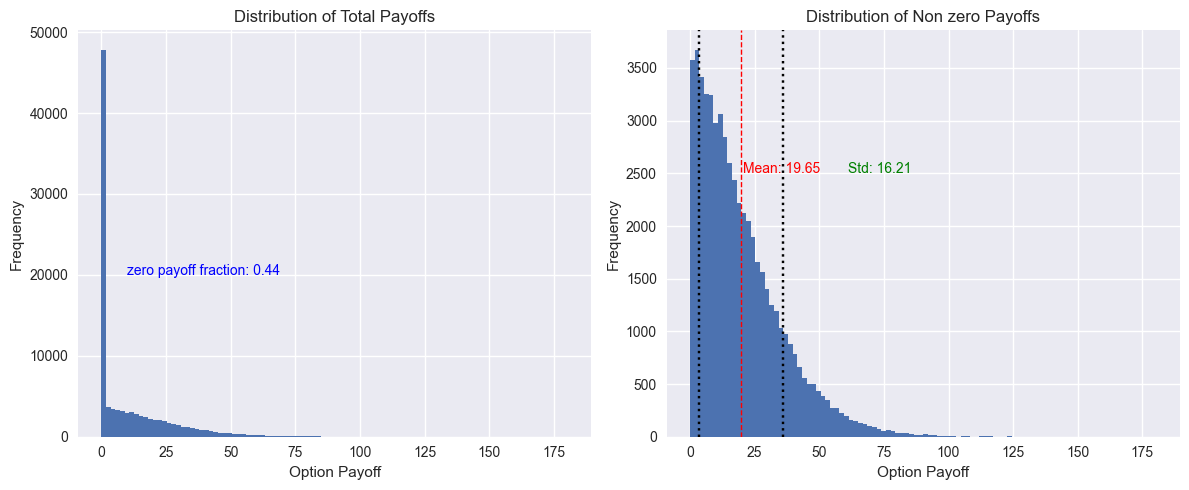

In [9]:
payoff = compute_payoff(terminal, strike, option_type="call")
zero_payoffs = payoff[payoff == 0]
nonzero_payoffs = payoff[payoff > 0]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

# Left — full distribution
# hint: plot the spike at zero separately using ax0.bar(0, height, width=0.5)
ax0.hist(payoff, bins=100)


# ax0.hist(nonzero_payoffs, bins=100)
# ax0.bar(0, 44000, width=1, color='red')
# then plot nonzero_payoffs as histogram
# annotate the zero fraction with ax0.text()
frac = len(zero_payoffs) / len(payoff)
ax0.text(10, 20000, f"zero payoff fraction: {frac:.2f}", color="blue")
ax0.set_xlabel("Option Payoff")
ax0.set_ylabel("Frequency")
ax0.set_title("Distribution of Total Payoffs")
# Right — non-zero tail only
# just histogram of nonzero_payoffs
ax1.hist(nonzero_payoffs, bins=100)

# annotate with mean and std of nonzero payoffs
mean_val = nonzero_payoffs.mean()
ax1.axvline(x=mean_val, linestyle="--", color="red", linewidth=1)
ax1.text(mean_val + 1, 2500, f"Mean: {mean_val:.2f}", color="red")

std_val = nonzero_payoffs.std()
# ax1.axvline(x=std_val, linestyle="--", color="green", linewidth=1)
ax1.text(std_val + 45, 2500, f"Std: {std_val:.2f}", color="green")
ax1.set_xlabel("Option Payoff")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Non zero Payoffs")
ax1.axvline(mean_val - std_val, linestyle=':', color='black')
ax1.axvline(mean_val + std_val, linestyle=':', color='black')
plt.tight_layout()

plt.savefig("../results/02_option_payoff_dist.png", dpi=150)
plt.show()

1. A spike at zero — the 44% of paths that expire worthless.

2. A continuous right tail — the 56% of paths that expire in the money. The shape of this tail comes from the log-normal distribution of $S_T$ shifted by $K$. It looks like the right half of the log-normal histogram you just plotted, starting from zero.
